# Practice Lab C: Regression Three Ways (TV Marketing)

**Area:** ml-connection · **Related lessons/concepts:** L42; Quiz 11; Homework 11; Grade 12 basic ch. 5

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Load the data (course file, with synthetic fallback)

(200, 2)
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


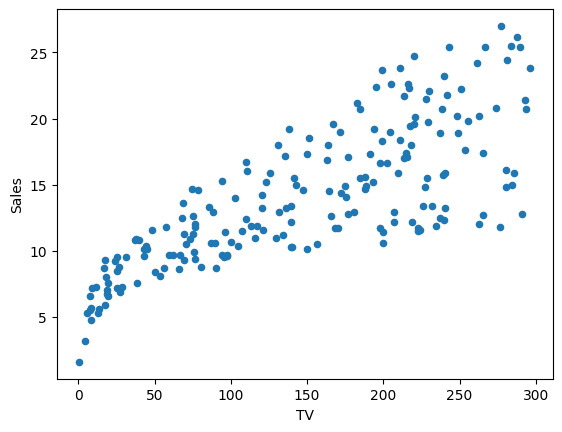

In [2]:
import os,pandas as pd
RAW="data/"  # optional course data; synthetic stand-in is used when absent
p=RAW+"C2/w2/C2w2_graded_lab/data/tvmarketing.csv"
if os.path.exists(p): df=pd.read_csv(p)
else:
    r=np.random.default_rng(0); tv=r.uniform(1,296,200); df=pd.DataFrame({"TV":tv,"Sales":7+0.0475*tv+r.normal(0,2.5,200)})
print(df.shape); print(df.head())
df.plot.scatter("TV","Sales"); plt.show()

## 2. Method 1 — the textbook formula (Grade 12 basic)

In [3]:
x=df.TV.values; y=df.Sales.values; n=len(x)
a=(n*(x*y).sum()-x.sum()*y.sum())/(n*(x**2).sum()-x.sum()**2); b=y.mean()-a*x.mean(); print("closed form:",a,b)

closed form: 0.04753664043301974 7.032593549127696


## 3. Methods 2–3 — polyfit and scikit-learn

In [4]:
print("polyfit:",np.polyfit(x,y,1))
from sklearn.linear_model import LinearRegression
m=LinearRegression().fit(x[:,None],y); print("sklearn:",m.coef_[0],m.intercept_)

polyfit: [0.0475 7.0326]


sklearn: 0.04753664043301979 7.0325935491276885


## 4. Method 4 — gradient descent (standardise first)

gradient descent: 0.0475366404330197 7.032593549127693


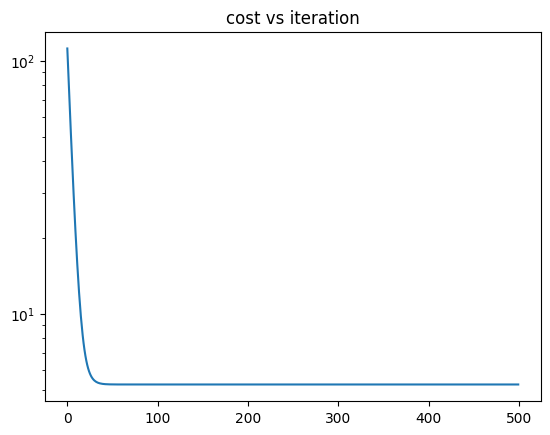

In [5]:
xs=(x-x.mean())/x.std(); w=bb=0.0; lr=0.1; hist=[]
for k in range(500):
    pred=w*xs+bb; err=pred-y
    w-=lr*np.mean(err*xs); bb-=lr*np.mean(err); hist.append(np.mean(err**2)/2)
slope=w/x.std(); icpt=bb-w*x.mean()/x.std(); print("gradient descent:",slope,icpt)
plt.plot(hist); plt.yscale('log'); plt.title("cost vs iteration"); plt.show()

## 5. Evaluate and inspect residuals

MSE 10.512652915656753 R^2 0.611875050850071 mean residual -1.2434497875801752e-15


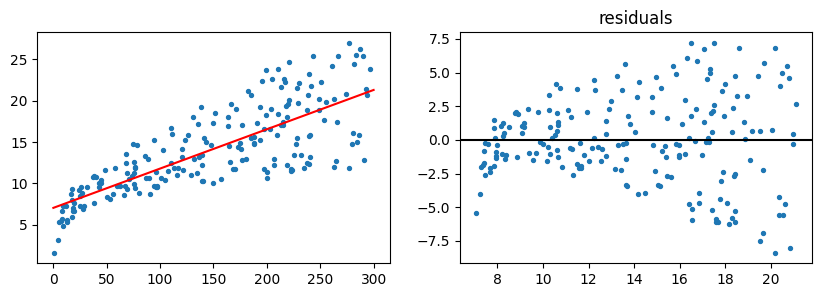

passes through mean point: True


In [6]:
pred=a*x+b; res=y-pred
mse=np.mean(res**2); r2=1-res.var()/y.var(); print("MSE",mse,"R^2",r2,"mean residual",res.mean())
fig,ax=plt.subplots(1,2,figsize=(10,3)); ax[0].scatter(x,y,s=8); xx=np.linspace(0,300,50); ax[0].plot(xx,a*xx+b,'r'); ax[1].scatter(pred,res,s=8); ax[1].axhline(0,c='k'); ax[1].set_title("residuals"); plt.show()
print("passes through mean point:",np.isclose(a*x.mean()+b,y.mean()))

## Exercises

**Exercise 1.** Predict sales for a TV budget of 200 and give a rough 95% prediction interval (±2 residual std).

In [7]:
# your code here

**Exercise 2.** Confirm all four methods agree to 3 decimals.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
s=res.std(ddof=2); p200=a*200+b; print(p200,p200-2*s,p200+2*s); assert p200>y.mean()

16.539921635731645 10.02260889843072 23.05723437303257


In [10]:
# Solution 2
assert np.allclose([a,b],np.polyfit(x,y,1),atol=1e-6) and abs(slope-a)<1e-3 and abs(icpt-b)<1e-2